<a href="https://colab.research.google.com/github/saratouahri/urban_climate_ml/blob/main/urban_climate_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Urban Climate & Weather ML Analysis

This notebook fetches historical daily weather data from **Open-Meteo** (no API key required) for major urban areas, engineers time-series features, and trains a machine learning model to predict next-day maximum temperature.

 **Colab Ready** |  **Time-Series Safe Split** |  **Scikit-Learn + Pandas**

In [ ]:
# 📦 Install lightweight dependencies if needed
!pip install -q requests pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
import time

warnings.filterwarnings('ignore')
print("✅ Dependencies loaded")

✅ Dependencies loaded


In [ ]:
# Fetch Historical Weather Data from Open-Meteo Archive API
def fetch_city_weather(lat, lon, city, start='2020-01-01', end='2023-12-31'):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum",
        "timezone": "auto"
    }
    res = requests.get(url, params=params)
    data = res.json()['daily']
    df = pd.DataFrame(data)
    df['city'] = city
    df.rename(columns={'time': 'date'}, inplace=True)
    df['date'] = pd.to_datetime(df['date'])
    time.sleep(1)  # Be polite to the API
    return df

# Fetch data for 4 major cities
cities = [
    (51.5074, -0.1278, 'London'),
    (40.7128, -74.0060, 'New York'),
    (35.6895, 139.6917, 'Tokyo'),
    (-33.8688, 151.2093, 'Sydney')
]

dfs = [fetch_city_weather(lat, lon, name) for lat, lon, name in cities]
df = pd.concat(dfs, ignore_index=True)
df.sort_values(['city', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"✅ Data shape: {df.shape} | Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

✅ Data shape: (5844, 7) | Date range: 2020-01-01 to 2023-12-31


,date,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,city
0,2020-01-01,6.6,2.0,0.0,10.2,1.57,London
1,2020-01-02,9.9,5.7,0.0,26.6,1.71,London
2,2020-01-03,10.8,3.3,3.1,27.6,2.12,London
3,2020-01-04,8.1,2.0,0.0,20.2,3.69,London
4,2020-01-05,8.6,2.2,0.0,17.4,2.04,London


In [ ]:
# 🧹 Preprocessing & Feature Engineering
# Set 'date' as index first for time-based interpolation
df.set_index('date', inplace=True)

# Handle missing values (Open-Meteo occasionally has gaps)
df.interpolate(method='time', inplace=True)
df.ffill(inplace=True)

# Create target: next day's max temperature
df['temp_max_next'] = df.groupby('city')['temperature_2m_max'].shift(-1)
df.dropna(subset=['temp_max_next'], inplace=True)

# Time-based features
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year']/365)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year']/365)
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

# Add temperature range feature
df['temp_range'] = df['temperature_2m_max'] - df['temperature_2m_min']

# Lag & Rolling features (per city)
for lag in [1, 2, 3, 7, 14, 30]: # Added lags 7, 14, 30
    df[f'temp_max_lag{lag}'] = df.groupby('city')['temperature_2m_max'].shift(lag)
df['temp_max_rolling7_mean'] = df.groupby('city')['temperature_2m_max'].transform(lambda x: x.shift(1).rolling(7).mean())
df['temp_max_rolling7_std'] = df.groupby('city')['temperature_2m_max'].transform(lambda x: x.shift(1).rolling(7).std())

# One-Hot Encode Cities
df = pd.get_dummies(df, columns=['city'], drop_first=False)

# Add city-specific seasonal interactions (after one-hot encoding)
df['london_winter'] = ((df.index.month.isin([12, 1, 2])) & (df['city_London'] == 1)).astype(int)
df['sydney_summer'] = ((df.index.month.isin([12, 1, 2])) & (df['city_Sydney'] == 1)).astype(int)

# Clean up
df.dropna(inplace=True)

# Define features & target
feature_cols = [c for c in df.columns if c not in ['temp_max_next', 'temperature_2m_max', 'temperature_2m_min', 'day_of_year', 'month']]
X = df[feature_cols]
y = df['temp_max_next']
print(f"✅ Features: {len(feature_cols)} | Samples: {len(X)}")

✅ Features: 22 | Samples: 5720


In [ ]:
# 📊 Time-Series Train/Test Split & Scaling
# Prevent future leakage: split chronologically
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"✅ Train: {X_train.shape} | Test: {X_test.shape}")

✅ Train: (4576, 22) | Test: (1144, 22)


In [ ]:
# 🤖 Train Machine Learning Model
from xgboost import XGBRegressor # Import XGBoost

model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42) # Changed to XGBoost
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📈 Model Evaluation (Next-Day Max Temp Prediction):")
print(f"   MAE : {mae:.3f}°C")
print(f"   RMSE: {rmse:.3f}°C")
print(f"   R²  : {r2:.3f}")

📈 Model Evaluation (Next-Day Max Temp Prediction):
   MAE : 2.379°C
   RMSE: 3.016°C
   R²  : 0.864


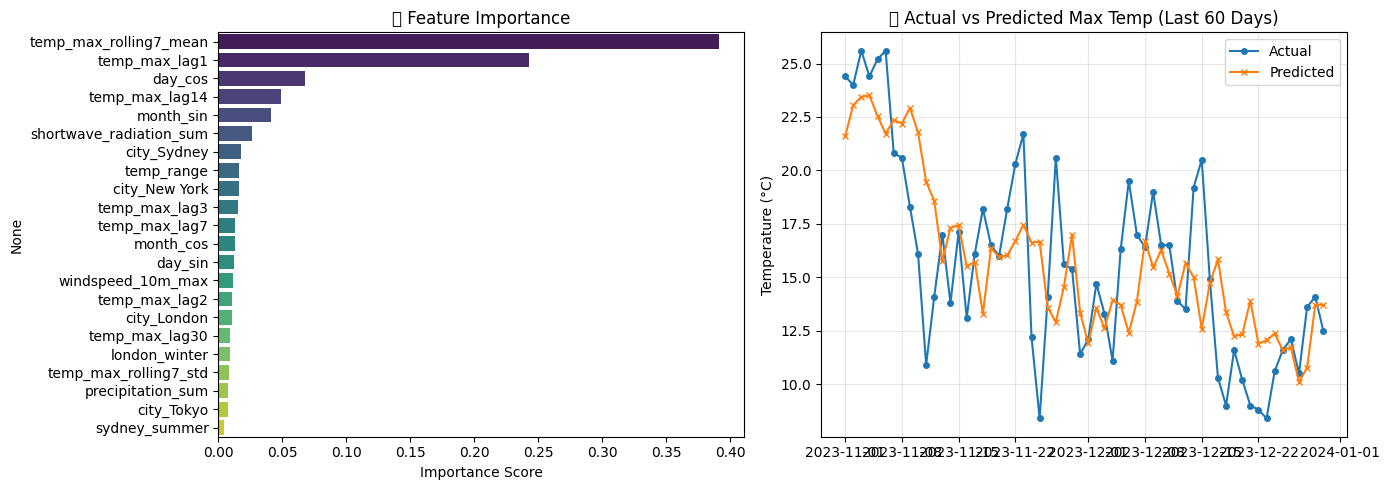

In [ ]:
# Get feature importances from the best model (after tuning, if applicable)
# If tuning was skipped, 'model' will be the directly trained XGBoost.
# If tuning was performed, 'best_model' from GridSearchCV should be used.

# Check if best_model exists from hyperparameter tuning, otherwise use the initial model
if 'best_model' in locals():
    model_to_visualize = best_model
else:
    model_to_visualize = model

importances = pd.Series(model_to_visualize.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature Importance
sns.barplot(x=importances.values, y=importances.index, ax=axes[0], palette='viridis')
axes[0].set_title('🔑 Feature Importance')
axes[0].set_xlabel('Importance Score')

# Actual vs Predicted (Last 60 days of test set)
test_dates = y_test.index[-60:]
axes[1].plot(test_dates, y_test.loc[test_dates], label='Actual', marker='o', markersize=4)

# Determine which y_pred to use for visualization
if 'y_pred_tuned' in locals():
    predictions_to_plot = y_pred_tuned
else:
    predictions_to_plot = y_pred

axes[1].plot(test_dates, predictions_to_plot[-len(test_dates):], label='Predicted', marker='x', markersize=4)
axes[1].set_title('📅 Actual vs Predicted Max Temp (Last 60 Days)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()